#Phase 2: Return Analysis


#1. Imports


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root= Path.cwd().parent
sys.path.append(str(project_root))

#2. Load Processed Data

In [2]:
data_path = project_root / "data" / "processed" / "close_prices.csv"

close_prices = pd.read_csv(
    data_path,
    header=0,
    index_col=0,
    parse_dates=True

)

close_prices.head()

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
Date,,,,,,,,
2016-01-04,48.184063,169.471527,90.649773,102.889999,75.337540,23.709103,49.319618,30.555977
2016-01-05,48.267376,169.758163,90.284065,103.180000,75.652466,23.114969,49.739830,30.664070
2016-01-06,47.570595,167.616806,91.500671,104.669998,75.270058,22.662619,49.325989,30.498310
2016-01-07,45.646870,163.595444,91.664879,106.150002,74.392830,21.706146,48.536484,29.993862
2016-01-08,44.624420,161.799683,92.075424,105.680000,73.598053,21.820925,47.555927,29.914583


#3. Calculate Daily Returns

In [3]:
daily_returns = close_prices.pct_change()

daily_returns.head()

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
Date,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,0.001729,0.001691,-0.004034,0.002819,0.004180,-0.025059,0.008520,0.003538
2016-01-06,-0.014436,-0.012614,0.013475,0.014441,-0.005055,-0.019570,-0.008320,-0.005406
2016-01-07,-0.040439,-0.023991,0.001795,0.014140,-0.011654,-0.042205,-0.016006,-0.016540
2016-01-08,-0.022399,-0.010977,0.004479,-0.004428,-0.010684,0.005288,-0.020202,-0.002643


In [4]:
daily_returns = daily_returns.dropna()

daily_returns.head()

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
Date,,,,,,,,
2016-01-05,0.001729,0.001691,-0.004034,0.002819,0.004180,-0.025059,0.008520,0.003538
2016-01-06,-0.014436,-0.012614,0.013475,0.014441,-0.005055,-0.019570,-0.008320,-0.005406
2016-01-07,-0.040439,-0.023991,0.001795,0.014140,-0.011654,-0.042205,-0.016006,-0.016540
2016-01-08,-0.022399,-0.010977,0.004479,-0.004428,-0.010684,0.005288,-0.020202,-0.002643
2016-01-11,-0.001528,0.000990,-0.010944,-0.008895,-0.006010,0.016192,-0.013389,0.001686


In [5]:
daily_returns.isnull().sum()

JPM     0
SPY     0
TLT     0
GLD     0
JNJ     0
AAPL    0
XOM     0
KO      0
dtype: int64

In [6]:
daily_returns.describe()

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
count,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000
mean,0.000895,0.000623,0.000012,0.000545,0.000529,0.001155,0.000586,0.000439
std,0.017263,0.011218,0.009290,0.010233,0.011643,0.018216,0.017608,0.011446
min,-0.149649,-0.109424,-0.066683,-0.102742,-0.100379,-0.128647,-0.122248,-0.096725
25%,-0.007020,-0.003581,-0.005547,-0.004636,-0.004778,-0.007109,-0.008189,-0.004768
50%,0.000819,0.000731,0.000295,0.000669,0.000466,0.001096,0.000583,0.000643
75%,0.008979,0.005948,0.005380,0.005635,0.006081,0.010023,0.009399,0.005968
max,0.180125,0.105019,0.075195,0.063587,0.079977,0.153289,0.126868,0.064796


#4. Explore daily Returns

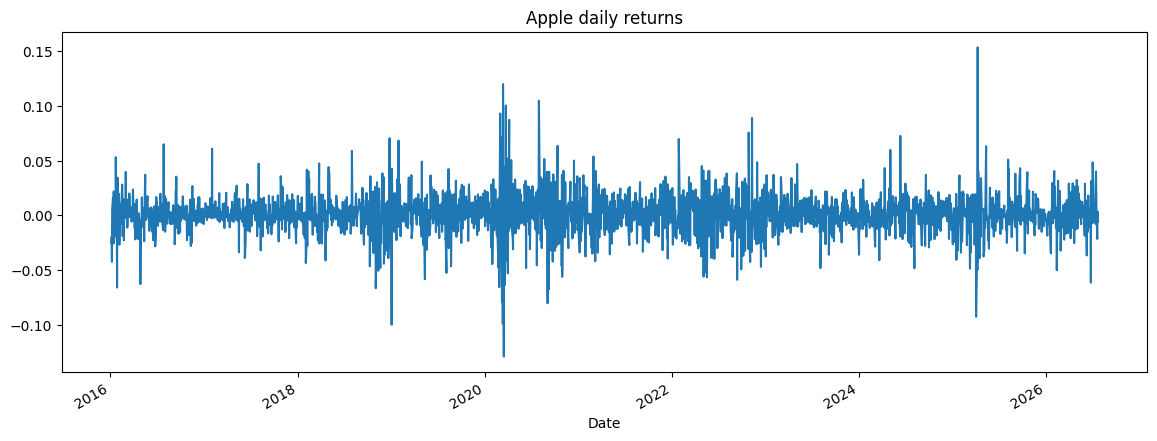

In [7]:
daily_returns["AAPL"].plot(figsize =(14,5), title= "Apple daily returns")

plt.show()

#5. Cumulative Returns


In [8]:
cumulative_returns = (1 + daily_returns).cumprod()

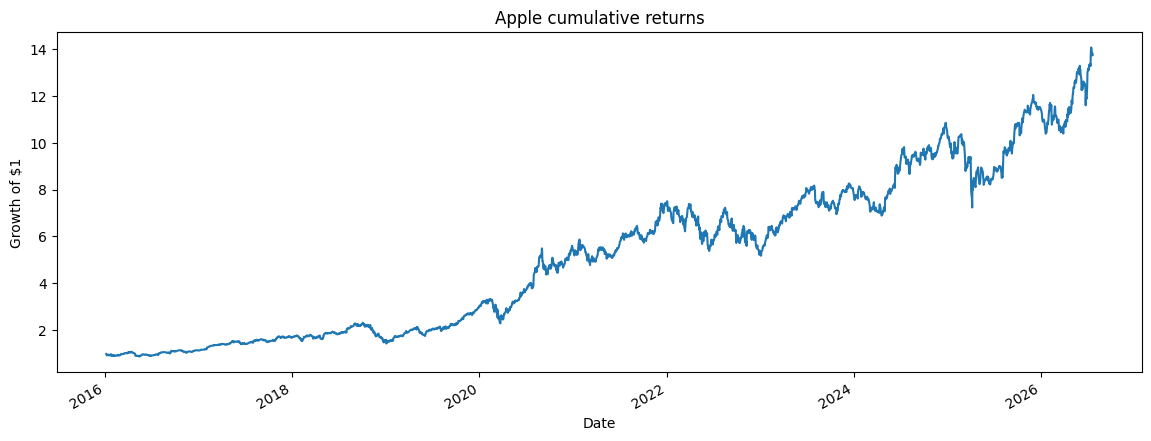

In [9]:
cumulative_returns["AAPL"].plot(
    figsize = (14,5),
    title = "Apple cumulative returns"
)

plt.ylabel("Growth of $1")
plt.show()

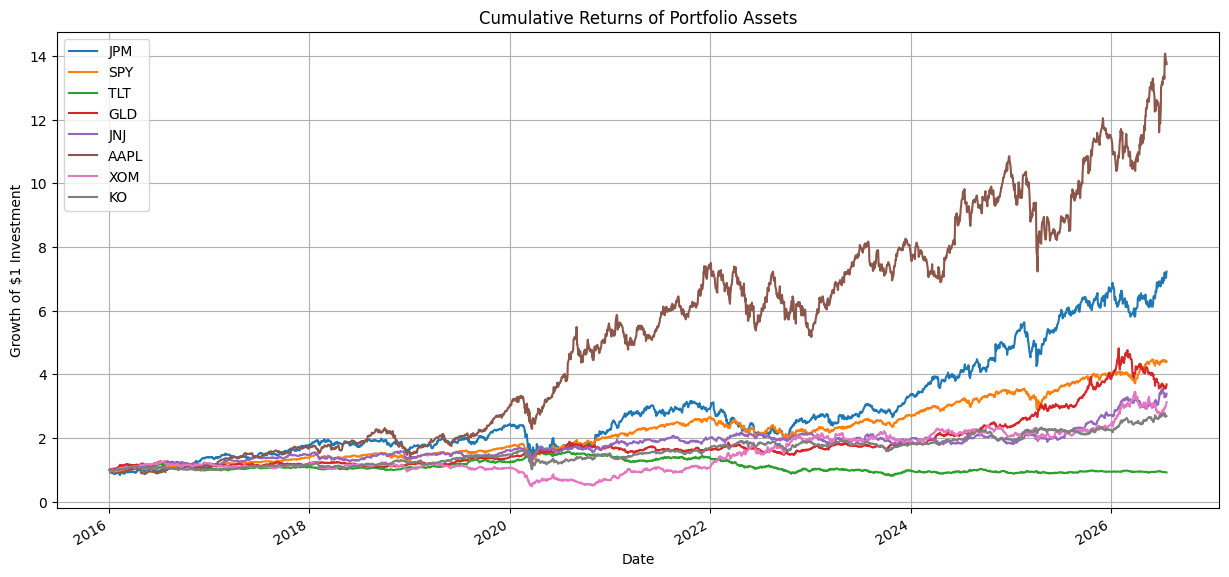

In [10]:
cumulative_returns.plot(figsize=(15,7))

plt.title("Cumulative Returns of Portfolio Assets")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")

plt.grid(True)
plt.show()

In [11]:
total_returns = (cumulative_returns.iloc[-1] - 1) * 100

total_returns.sort_values(ascending=False)

AAPL    1274.535425
JPM      622.666313
SPY      341.023921
GLD      268.471180
JNJ      239.312919
XOM      213.161380
KO       169.014463
TLT       -7.953434
Name: 2026-07-22 00:00:00, dtype: float64

In [12]:
daily_returns.to_csv(
    project_root / "data" / "processed" / "daily_returns.csv"
)

print("Daily returns saved successfully!")

Daily returns saved successfully!


# Correlation Matrix


In [13]:
correlation_matrix = daily_returns.corr()
correlation_matrix

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
JPM,1.000000,0.701697,-0.307057,-0.063800,0.329744,0.407726,0.503279,0.385279
SPY,0.701697,1.000000,-0.155990,0.076342,0.428062,0.741368,0.486361,0.491976
TLT,-0.307057,-0.155990,1.000000,0.259906,-0.086755,-0.092116,-0.237250,-0.071798
GLD,-0.063800,0.076342,0.259906,1.000000,0.043699,0.035133,0.036421,0.044607
JNJ,0.329744,0.428062,-0.086755,0.043699,1.000000,0.289434,0.283459,0.494959
AAPL,0.407726,0.741368,-0.092116,0.035133,0.289434,1.000000,0.277226,0.323400
XOM,0.503279,0.486361,-0.237250,0.036421,0.283459,0.277226,1.000000,0.355110
KO,0.385279,0.491976,-0.071798,0.044607,0.494959,0.323400,0.355110,1.000000


# Histogram of returns


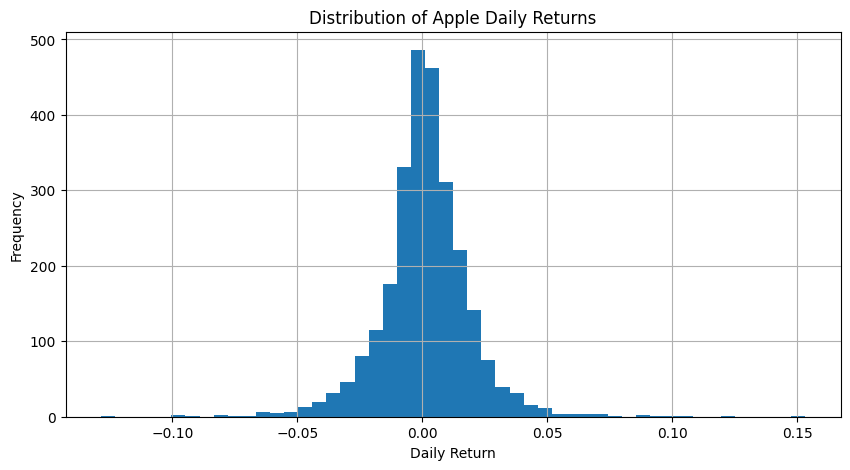

In [14]:
daily_returns["AAPL"].hist(
    bins=50,
    figsize=(10,5)
)

plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()